In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.DataFrame({"Age": [0, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 200]})

In [3]:
data

,Age
0,0
1,25
2,30
3,35
4,40
5,45
6,50
7,55
8,60
9,65


<Axes: xlabel='Age', ylabel='Count'>

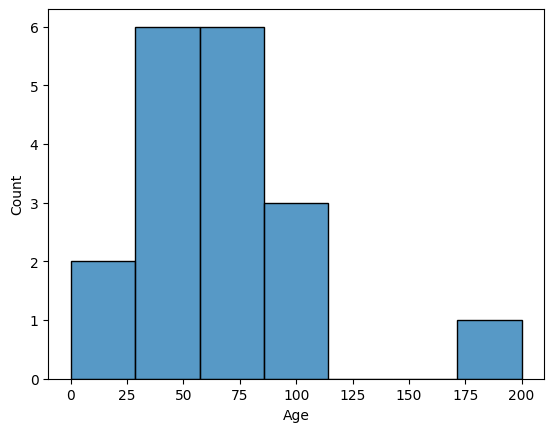

In [6]:
sns.histplot(data=data, x="Age")

<Axes: xlabel='Age'>

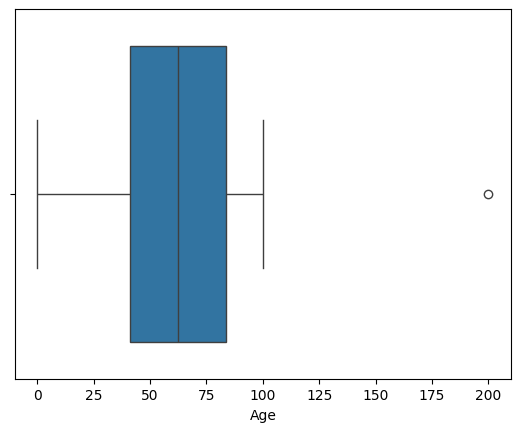

In [7]:
sns.boxplot(data=data, x="Age")

In [12]:
data["mean"] = np.mean(data["Age"])
data["std"] = np.std(data["Age"])
print(f"Mean: {data['mean'].iloc[0]}, Standard Deviation: {data['std'].iloc[0]}")

Mean: 66.66666666666667, Standard Deviation: 41.499665326629106


In [13]:
data['Z_score'] = (data['Age'] - mean) / std
data

,Age,Z_score,mean,std
0,0,-1.606439,66.666667,41.499665
1,25,-1.004024,66.666667,41.499665
2,30,-0.883541,66.666667,41.499665
3,35,-0.763058,66.666667,41.499665
4,40,-0.642575,66.666667,41.499665
5,45,-0.522093,66.666667,41.499665
6,50,-0.401610,66.666667,41.499665
7,55,-0.281127,66.666667,41.499665
8,60,-0.160644,66.666667,41.499665
9,65,-0.040161,66.666667,41.499665


In [14]:
print(f"Outliers (Z-score > 3 or < -3):\n{data[(data['Z_score'] > 3) | (data['Z_score'] < -3)]}")

Outliers (Z-score > 3 or < -3):
    Age   Z_score       mean        std
17  200  3.212877  66.666667  41.499665


In [15]:
data = data[(data['Z_score'] <= 3) & (data['Z_score'] >= -3)]
data

,Age,Z_score,mean,std
0,0,-1.606439,66.666667,41.499665
1,25,-1.004024,66.666667,41.499665
2,30,-0.883541,66.666667,41.499665
3,35,-0.763058,66.666667,41.499665
4,40,-0.642575,66.666667,41.499665
5,45,-0.522093,66.666667,41.499665
6,50,-0.401610,66.666667,41.499665
7,55,-0.281127,66.666667,41.499665
8,60,-0.160644,66.666667,41.499665
9,65,-0.040161,66.666667,41.499665


In [16]:
import scipy.stats as stats

In [17]:
data = [2.5, 2.7, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 110.0] 

In [ ]:
z_scores = np.abs(stats.zscore(data)) # all will +ve because of abs
print(f"Z-scores: {z_scores}")

Z-scores: [0.37399684 0.36803937 0.36506063 0.35910316 0.35314569 0.34420948
 0.33527327 0.3293158  2.82814425]


In [24]:
threshold = 2.5
outliers = np.where(z_scores > threshold)
print(f"Outliers (Z-score > {threshold}): {outliers[0]} with values {[data[i] for i in outliers[0]]}")

Outliers (Z-score > 2.5): [8] with values [110.0]


In [28]:
print(data)
print(outliers)
print(f"Outliers: {[data[i] for i in outliers[0]]}")
# data withoutliers removed
data_no_outliers = [data[i] for i in range(len(data)) if i not in outliers[0]]
print(f"Data without outliers: {data_no_outliers}")


[2.5, 2.7, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 110.0]
(array([8]),)
Outliers: [110.0]
Data without outliers: [2.5, 2.7, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0]
